In [3]:
import numpy as np
import pandas as pd

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
import string
import re
import os
from string import digits
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import datetime
import csv

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences, to_categorical
from tensorflow.keras.layers import Embedding, Dense, LSTM, Input
from tensorflow.keras.models import Model
from keras.utils import plot_model

In [5]:
df = pd.read_csv('archive/political_Bias.csv' , encoding = 'utf-8')
df.head()

,Title,Link,Text,Source,Bias
0,John Boltonâ€™s Advice for the â€˜Continuing T...,https://thedispatch.com/article/john-boltons-a...,"With just days until his inauguration, it woul...",TheDispatch,lean right
1,Why Shrubland Makes Southern Californiaâ€™s Wi...,https://thedispatch.com/newsletter/techne/why-...,"Welcome back to Techne! In Star Trek, writers ...",TheDispatch,lean right
2,Los Angelesâ€™ Destruction Was Fueled by Bad P...,https://thedispatch.com/newsletter/capitolism/...,"As fire still rages in the Los Angeles area, I...",TheDispatch,lean right
3,Acquiring Greenland Is a Good Idea. Threatenin...,https://thedispatch.com/article/acquiring-gree...,"Whether it was Will Rogers or Tony Soprano, th...",TheDispatch,lean right
4,Assessing Trumpâ€™s Expansionist Designs,https://thedispatch.com/newsletter/morning/ass...,"Happy Friday! If anyone was wondering, Belgium...",TheDispatch,lean right


In [6]:
df[df.isna().any(axis=1)]

,Title,Link,Text,Source,Bias
16,Biden pardons his family in final minutes in o...,https://www.cnbc.com/2025/01/20/biden-pardons-...,NaN,cnbc,center
17,"Biden pardons Dr. Anthony Fauci, Gen. Milley, ...",https://www.cnbc.com/2025/01/20/biden-pardons-...,NaN,cnbc,center
19,"As America braces for Trump 2.0, here's how th...",https://www.cnbc.com/2025/01/20/how-the-rest-o...,NaN,cnbc,center
25,Trump says he's thinking of imposing 25% tarif...,https://www.cnbc.com/2025/01/20/trump-says-hes...,NaN,cnbc,center
26,Trump's crypto-frenzied inauguration weekend m...,https://www.cnbc.com/2025/01/20/trump-crypto-f...,NaN,cnbc,center
...,...,...,...,...,...
2723,Four female Israeli hostages released by Hamas...,https://www.nbcnews.com/news/world/live-blog/h...,NaN,nbcnews,lean left
2725,Trump Day 7 dropdown with sub links,https://www.nbcnews.com/politics/donald-trump/...,NaN,nbcnews,lean left
2726,NFL playoffs dropdown with sub links,https://www.nbcnews.com/sports/nfl/live-blog/n...,NaN,nbcnews,lean left
2727,Live updates: Eagles beat the Commanders 55-23...,https://www.nbcnews.com/sports/nfl/live-blog/n...,NaN,nbcnews,lean left


In [7]:
df['Text'] = df['Text'].fillna("Textmissing")

punctuation_set = {
    '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', 
    ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~',
    '।', '“', '”', '‘', '’', '॥', '…', '॰'
}

df['Text'] = df['Text'].apply(lambda x: ''.join(ch for ch in x if ch not in punctuation_set))

remove_digits = str.maketrans('', '', digits)
df['Text'] = df['Text'].apply(lambda x: x.translate(remove_digits))
df['Text']=df['Text'].apply(lambda x: x.strip())
df['Text'] = df['Text'].apply(lambda x: re.sub(r'\s+', ' ', x))
df['Text'] = df['Text'].apply(lambda x: x.lower())
df['Text_seq_length'] = df['Text'].apply(lambda x: len(x.split(' ')))
df.head(3)

,Title,Link,Text,Source,Bias,Text_seq_length
0,John Boltonâ€™s Advice for the â€˜Continuing T...,https://thedispatch.com/article/john-boltons-a...,with just days until his inauguration it would...,TheDispatch,lean right,1015
1,Why Shrubland Makes Southern Californiaâ€™s Wi...,https://thedispatch.com/newsletter/techne/why-...,welcome back to techne in star trek writers go...,TheDispatch,lean right,2023
2,Los Angelesâ€™ Destruction Was Fueled by Bad P...,https://thedispatch.com/newsletter/capitolism/...,as fire still rages in the los angeles area iâ...,TheDispatch,lean right,338


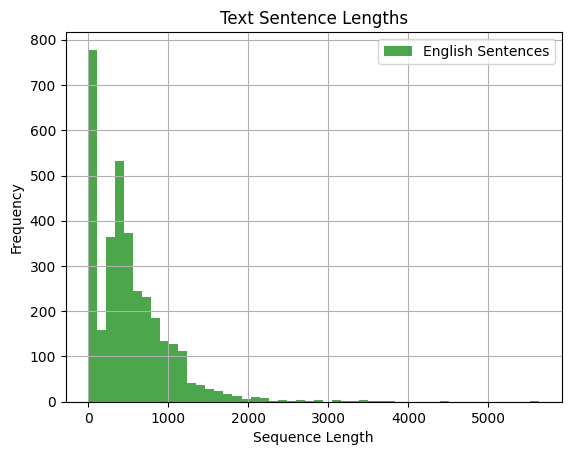

In [8]:
df.hist(column="Text_seq_length", bins=50, alpha=0.7, color='green', label='English Sentences')
plt.title('Text Sentence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.show()

In [9]:
df[df['Text_seq_length']>1000].shape

(479, 6)

In [10]:
df = df[df['Text_seq_length']<1000]
df.shape

(2978, 6)

In [11]:
Text_sentences = df['Text'].apply(lambda x: x+' END')

In [12]:
Text_tokenizer = Tokenizer(filters='')
Text_tokenizer.fit_on_texts(Text_sentences)
num_encoder_tokens = len(Text_tokenizer.word_index) + 1

In [13]:
Text_sequences = Text_tokenizer.texts_to_sequences(Text_sentences)

In [14]:
with open('Text_tokenizer.pkl', 'wb') as f:
    pickle.dump(Text_tokenizer, f)

SetFit methods *DONE*,TO DO: make the input to take news file (i.e pdf, word, or etc)

In [2]:
import pandas as pd
from datasets import Dataset
from setfit import SetFitModel, Trainer, TrainingArguments

df = pd.read_csv('archive/Political_Bias.csv')

df['text'] = df['Title'].fillna('') + " " + df['Text'].str[:1000].fillna('')

# SetFit requirement
label_map = {
    'left': 0, 
    'lean left': 1, 
    'center': 2, 
    'lean right': 3, 
    'right': 4
}
df['label'] = df['Bias'].str.lower().map(label_map)

df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

# Convert to HuggingFace Dataset format and Split
full_dataset = Dataset.from_pandas(df[['text', 'label']])
dataset_split = full_dataset.train_test_split(test_size=0.2)
train_dataset = dataset_split['train']
eval_dataset = dataset_split['test']

model = SetFitModel.from_pretrained(
    "sentence-transformers/paraphrase-MiniLM-L3-v2", #Could use a bigger model for a more accurate predictions
    head_params={"max_iter": 1000} 
)

# Training Arguments
args = TrainingArguments(
    batch_size=4,
    num_epochs=1,          
    max_steps=100,         # Keeps training short to save on processing power
    use_amp=True,          # Use Mixed Precision if using an NVIDIA GPU
)

# Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset, 
    eval_dataset=eval_dataset,  
    column_mapping={"text": "text", "label": "label"} 
)

# Train and Save
print("Starting local training...")
trainer.train()

# Evaluate accuracy
metrics = trainer.evaluate()
print(f"Model Accuracy: {metrics['accuracy'] * 100:.2f}%")

model.save_pretrained("news_bias_setfit_model")

# (Testing a new article)
new_news = "The senate passed a landmark climate bill today despite heavy opposition."
probs = model.predict_proba([new_news])

# Format output
output_label = model.predict([new_news])[0].item() 
reverse_map = {v: k for k, v in label_map.items()}

confidence = probs[0][output_label].item()

print(f"Predicted Bias: {reverse_map[output_label]}")
print(f"Confidence Score: {confidence:.4f}")

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
c:\Users\MyBook Hype AMD\Documents\GitHub\Political-Biases\projt.venv\Lib\site-packages\datasets\utils\_dill.py:379: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  obj.co_lnotab,  # for < python 3.10 [not counted in args]
Map: 100%|██████████| 2766/2766 [00:00<00:00, 15920.11 examples/s]


Starting local training...


***** Running training *****
  Num unique pairs = 1434
  Batch size = 4
  Num epochs = 1
  Total optimization steps = 100
  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\MyBook Hype AMD\Documents\GitHub\Political-Biases\projt.venv\Lib\site-packages\setfit\trainer.py:574: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
c:\Users\MyBook Hype AMD\Documents\GitHub\Political-Biases\projt.venv\Lib\site-packages\torch\cuda\amp\grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(
  0%|          | 0/100 [00:02<?, ?it/s]
c:\Users\MyBook Hype AMD\Documents\GitHub\Political-Biases\projt.venv\Lib\site-packages\setfit\trainer.py:629: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
c:\Users\MyBook Hype AMD\Documents\Gi

{'embedding_loss': 0.4827, 'learning_rate': 2.0000000000000003e-06, 'epoch': 0.0}


{'embedding_loss': 0.2718, 'learning_rate': 1.1111111111111113e-05, 'epoch': 0.14}



                                              
100%|██████████| 100/100 [00:54<00:00,  1.85it/s]


{'embedding_loss': 0.291, 'learning_rate': 0.0, 'epoch': 0.28}
{'train_runtime': 56.2495, 'train_samples_per_second': 7.111, 'train_steps_per_second': 1.778, 'epoch': 0.28}


***** Running evaluation *****


Model Accuracy: 61.85%
Predicted Bias: right
Confidence Score: 0.5042


RAG Method (Retrieval Augmented Generation)

In [4]:
# Force-install the core and the community integrations
%pip install --upgrade langchain langchain-core langchain-community langchain-text-splitters

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


NOT FINISH, FIX LATER AND TRY ON PC!

In [1]:
import pandas as pd
from langchain_community.document_loaders import DataFrameLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_community.llms import Ollama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# 1. Load Data
df = pd.read_csv('archive/Political_Bias.csv')
df['page_content'] = "Title: " + df['Title'].fillna('') + "\nContent: " + df['Text'].str[:1000].fillna('')
loader = DataFrameLoader(df, page_content_column="page_content")
docs = loader.load()

# 2. Split & Embed
splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=50)
chunks = splitter.split_documents(docs)
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_db = Chroma.from_documents(chunks, embeddings)
retriever = vector_db.as_retriever()

# 3. Define the Brain (Ollama)
llm = Ollama(model="llama3")

# 4. Create the Prompt Template
template = """Answer the question based only on the following context:
{context}

Question: {question}
"""
prompt = ChatPromptTemplate.from_template(template)

# 5. Build the Chain (The Modern Way - No 'langchain.chains' needed!)
rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

# 6. Test
print("System ready. Analyzing...")
print(rag_chain.invoke("What are the key themes in articles with a Left bias?"))

c:\Users\MyBook Hype AMD\Documents\GitHub\Political-Biases\projt.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\MyBook Hype AMD\AppData\Local\Temp\ipykernel_6944\2607775982.py:20: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
c:\Users\MyBook Hype AMD\Documents\GitHub\Political-Biases\projt.venv\Lib\site-packages\huggingface_hub\file_download.py:148: UserWarning: `huggingface_hub` cache-system uses symlin

System ready. Analyzing...


OllamaEndpointNotFoundError: Ollama call failed with status code 404. Maybe your model is not found and you should pull the model with `ollama pull llama3`.